In [1]:
# 
# DEPENDENCY INSTALLATION
# Run this cell FIRST before any other.
# Installs the necessary packages if they are not present in the environment.
# 

import subprocess, sys

def install(package):
    """Installs a package via pip if it is not already installed."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# List of packages required for this project
required_packages = [
    "xgboost",           # XGBoost algorithm (Extreme Gradient Boosting)
    "imbalanced-learn",  # Library with SMOTE (only needed in Notebook 1)
    "scikit-learn",      # ML algorithms, metrics and preprocessing
    "pandas",            # Data manipulation in DataFrames
    "numpy",             # Mathematical operations and arrays
    "matplotlib",        # Basic graphical visualizations
    "seaborn",           # Advanced statistical visualizations
    "joblib",            # Save and load trained models
]

print("Checking and installing dependencies...")
for pkg in required_packages:
    try:
        __import__(pkg.replace("-", "_").split("[")[0])
        print(f"  ✓ {pkg} already installed")
    except ImportError:
        print(f"  ↓ Installing {pkg}...")
        install(pkg)
        print(f"  ✓ {pkg} installed successfully")

print()
print("All dependencies are ready! You can proceed to the next cell.")

Checking and installing dependencies...
  ✓ xgboost already installed
  ↓ Installing imbalanced-learn...
  ✓ imbalanced-learn installed successfully
  ↓ Installing scikit-learn...
  ✓ scikit-learn installed successfully
  ✓ pandas already installed
  ✓ numpy already installed
  ✓ matplotlib already installed
  ✓ seaborn already installed
  ✓ joblib already installed

All dependencies are ready! You can proceed to the next cell.


In [2]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 1: Library Import
# 

# pandas: data manipulation in DataFrames (tables)
import pandas as pd

# numpy: mathematical operations and numeric arrays
import numpy as np

# matplotlib.pyplot: creation of charts and visualizations
import matplotlib.pyplot as plt

# seaborn: elegant statistical visualizations built on matplotlib
import seaborn as sns

# warnings: suppress unnecessary warnings during execution
import warnings
warnings.filterwarnings('ignore')

# Visual configuration of the charts
sns.set_theme(style='whitegrid', palette='muted')  # Different palette from NB1 for visual distinction
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries imported successfully!")
print("Note: This is Notebook 2 — approach with scale_pos_weight (without SMOTE)")

Libraries imported successfully!
Note: This is Notebook 2 — approach with scale_pos_weight (without SMOTE)


In [3]:
#
# PHASE 2 – DATA UNDERSTANDING
# Cell 2: Loading and Initial Exploration of the Dataset
# 

# Loads the original IBM dataset with 7043 customers and 21 columns
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

print(f"Dataset dimensions: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Shows the first 5 rows to check the data structure
df.head()

Dataset dimensions: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


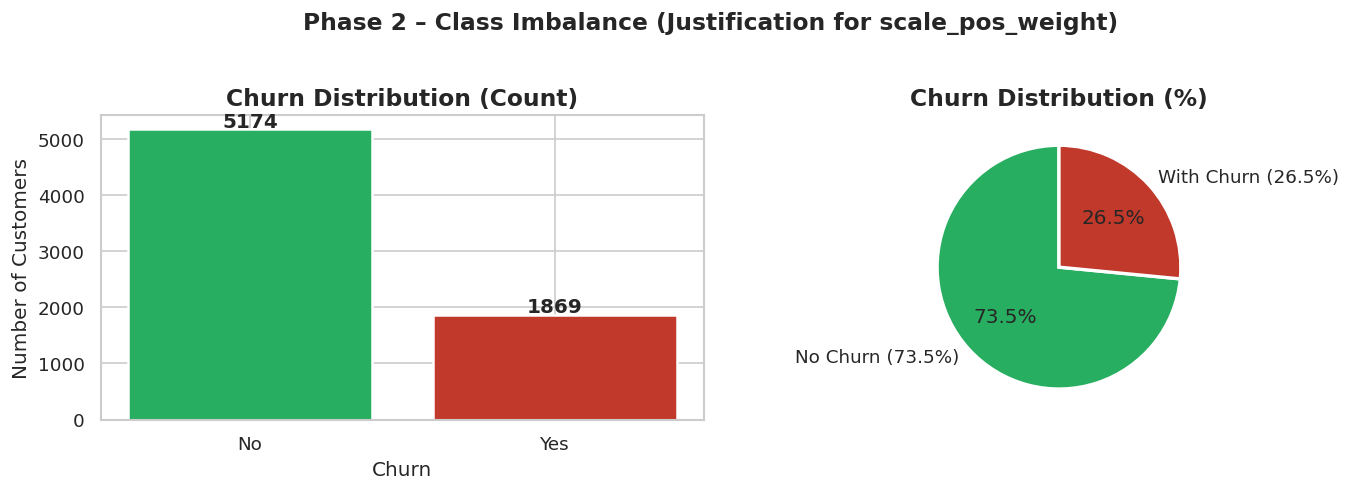

Customers without Churn (negative class): 5174
Customers with Churn (positive class): 1869
Imbalance ratio: 2.77
=> scale_pos_weight = 2.77
   This tells XGBoost: 'errors in the Churn class are worth 2.8x more than in the No Churn class'


In [4]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 3: Class Imbalance Analysis
# 

# This cell is fundamental to justify the use of scale_pos_weight:
# we show that the dataset is imbalanced and explain our solution

churn_counts = df['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart with the count of each class
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#27ae60', '#c0392b'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart with the percentages
axes[1].pie(churn_counts.values,
            labels=['No Churn (73.5%)', 'With Churn (26.5%)'],
            colors=['#27ae60', '#c0392b'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Phase 2 – Class Imbalance (Justification for scale_pos_weight)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/nb2_01_churn_distribution.png', bbox_inches='tight')
plt.show()

# Calculate the ratio for scale_pos_weight
n_neg = (df['Churn'] == 'No').sum()   # Number of customers who did NOT churn
n_pos = (df['Churn'] == 'Yes').sum()  # Number of customers who churned
ratio = n_neg / n_pos  # Imbalance ratio

print(f"Customers without Churn (negative class): {n_neg}")
print(f"Customers with Churn (positive class): {n_pos}")
print(f"Imbalance ratio: {ratio:.2f}")
print(f"=> scale_pos_weight = {ratio:.2f}")
print(f"   This tells XGBoost: 'errors in the Churn class are worth {ratio:.1f}x more than in the No Churn class'")

Fase 3 – Data Preparation (Preparação dos Dados)¶
A preparação dos dados é idêntica ao Notebook 1, com uma diferença crucial:

Não aplicamos SMOTE!

Em vez disso, os dados de treino são usados na sua distribuição original (desequilibrada). O desequilíbrio será tratado diretamente pelo parâmetro scale_pos_weight do XGBoost na fase de modelação.

Passos:

Corrigir tipos de dados
Tratar valores nulos
Remover customerID
Codificar variáveis binárias (Yes/No → 1/0)
One-Hot Encoding para variáveis multi-classe
Separar X e y
Dividir em treino (80%) e teste (20%)
Escalar variáveis numéricas
SEM SMOTE — o dataset de treino permanece desequilibrado

In [5]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 4: Imports for Preprocessing
# 

# train_test_split: splits the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler: normalizes numerical variables (mean=0, standard deviation=1)
from sklearn.preprocessing import StandardScaler

# NOTE: We do NOT import SMOTE in this notebook!
# Class imbalance will be handled by XGBoost's scale_pos_weight

print("Modules imported. SMOTE will NOT be used in this notebook.")
print("Class imbalance will be handled via scale_pos_weight in XGBoost.")

Modules imported. SMOTE will NOT be used in this notebook.
Class imbalance will be handled via scale_pos_weight in XGBoost.


In [6]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 5: Data Cleaning and Type Correction
# 

# Create a copy of the original DataFrame to preserve raw data
df_clean = df.copy()

# PROBLEM: TotalCharges is a string (text) because of white spaces
# SOLUTION: pd.to_numeric() with errors='coerce' converts to number
# and turns invalid values into NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Count null values created by the conversion
missing_before = df_clean['TotalCharges'].isnull().sum()

# Calculate the median for imputation (more robust than mean in presence of outliers)
median_val = df_clean['TotalCharges'].median()

# Replace NaNs with the median — median imputation technique
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_val)

print(f"TotalCharges: {missing_before} null values replaced by the median ({median_val:.2f})")

# Remove customerID — it is just an identifier, has no predictive power
df_clean.drop(columns=['customerID'], inplace=True)
print(f"Dimensions after removing customerID: {df_clean.shape}")

TotalCharges: 11 null values replaced by the median (1397.47)
Dimensions after removing customerID: (7043, 20)


In [7]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 6: Target Variable and Binary Variables Encoding
# 

# Encode the target variable: 'Yes' → 1 (churned), 'No' → 0 (did not churn)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
print("Target variable encoded: Yes=1, No=0")

# List of binary columns (Yes/No or variants like 'No phone service')
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Encode each binary column: 'Yes' → 1, anything else → 0
# The lambda function is applied to each individual value
for col in binary_cols:
    df_clean[col] = df_clean[col].map(lambda x: 1 if x == 'Yes' else 0)

# Encode gender: 'Female' → 0, 'Male' → 1
df_clean['gender'] = df_clean['gender'].map({'Female': 0, 'Male': 1})

# Ensure no NaNs remain and types are integers
df_clean[binary_cols + ['gender']] = df_clean[binary_cols + ['gender']].fillna(0).astype(int)

print("Binary encoding completed.")

Target variable encoded: Yes=1, No=0
Binary encoding completed.


In [8]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 7: One-Hot Encoding and Final Preparation
# 

# One-Hot Encoding for columns with more than 2 categories
# Each unique category becomes a new binary column (0 or 1)
# drop_first=True removes the first category to avoid multicollinearity
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

# Convert boolean columns (True/False) to integers (1/0)
# get_dummies() creates boolean columns in recent pandas versions
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Ensure there are no NaNs in the final dataset
df_clean = df_clean.fillna(0)

print("One-Hot Encoding completed.")
print("Dataset dimensions:", df_clean.shape)

One-Hot Encoding completed.
Dataset dimensions: (7043, 24)


In [9]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 8: Features / Target Separation and Train/Test Split
# 

# X: all columns except 'Churn' (independent variables / features)
X = df_clean.drop(columns=['Churn'])

# y: only the 'Churn' column (dependent variable / target)
y = df_clean['Churn']

# 80% train / 20% test split
# stratify=y ensures that the proportion of churners is equal in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Churn Rate in Train: {y_train.mean()*100:.1f}%  (IMBALANCED — without SMOTE)")
print(f"Churn Rate in Test:  {y_test.mean()*100:.1f}%")
print()
# Calculate scale_pos_weight based on TRAIN data
# Formula: number of negative examples / number of positive examples
n_neg_train = (y_train == 0).sum()
n_pos_train = (y_train == 1).sum()
scale_pos_weight = n_neg_train / n_pos_train
print(f"scale_pos_weight calculated from train: {scale_pos_weight:.4f}")
print(f"  ({n_neg_train} negative examples / {n_pos_train} positive examples)")
print(f"  Interpretation: XGBoost will treat each error on a churner as if it were {scale_pos_weight:.1f} normal errors")

Train: 5634 samples | Test: 1409 samples
Churn Rate in Train: 26.5%  (IMBALANCED — without SMOTE)
Churn Rate in Test:  26.5%

scale_pos_weight calculated from train: 2.7686
  (4139 negative examples / 1495 positive examples)
  Interpretation: XGBoost will treat each error on a churner as if it were 2.8 normal errors


In [10]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 9: Normalization of Numerical Variables
# 

# StandardScaler normalizes numerical variables to mean=0 and std=1
# Important for Logistic Regression (scale sensitive)
# XGBoost is scale insensitive, but we normalize for consistency
scaler = StandardScaler()
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# fit_transform() on TRAIN: learns parameters AND applies the transformation
X_train[num_features] = scaler.fit_transform(X_train[num_features])

# transform() on TEST: applies parameters learned on training (no re-learning)
# NEVER do fit() on test — avoids data leakage (information contamination)
X_test[num_features] = scaler.transform(X_test[num_features])

print("Normalization completed.")
print()
print("=== KEY DIFFERENCE compared to Notebook 1 ===")
print("NB1 (SMOTE):             Balanced training with synthetic data")
print(f"NB2 (scale_pos_weight):  UNBALANCED training ({y_train.mean()*100:.1f}% churn)")
print("                         XGBoost will internally compensate via scale_pos_weight")

Normalization completed.

=== KEY DIFFERENCE compared to Notebook 1 ===
NB1 (SMOTE):             Balanced training with synthetic data
NB2 (scale_pos_weight):  UNBALANCED training (26.5% churn)
                         XGBoost will internally compensate via scale_pos_weight


Fase 4 – Modelling (Modelação)
Neste notebook, o foco principal é o XGBoost com scale_pos_weight. Também treinamos Regressão Logística e Random Forest com class_weight='balanced' para comparação.

O que é scale_pos_weight?
O parâmetro scale_pos_weight do XGBoost controla o peso relativo da classe positiva (Churn=1) durante o treino. É calculado como:

scale_pos_weight = n_negativos / n_positivos
                 = 5174 / 1869 ≈ 2.77
Isto significa que o XGBoost trata cada erro num churner como se fossem 2.77 erros normais, forçando o modelo a prestar mais atenção à classe minoritária.

In [11]:
# 
# PHASE 4 – MODELLING
# Cell 10: Importing Models and Evaluation Function
# 

# Importa os algoritmos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Importa as métricas de avaliação
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, accuracy_score, precision_score, recall_score
)

# Dicionário para guardar os resultados de todos os modelos
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    # Trains a model, makes predictions, and calculates all evaluation metrics.
    # Saves the results in the global 'results' dictionary.
    # Trains the model with the training data
    model.fit(X_tr, y_tr)

    # predict() returns the predicted class (0 or 1)
    y_pred = model.predict(X_te)

    # predict_proba() returns the probability of each class
    # [:, 1] selects the probability of the positive class (Churn=1)
    y_prob = model.predict_proba(X_te)[:, 1]

    # Calculates all metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)

    # Saves in the global dictionary
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'ROC-AUC': auc,
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}  ← Most important metric for the business")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'With Churn']))

print("Evaluation function defined!")

Evaluation function defined!


In [12]:
# 
# PHASE 4 – MODELLING
# Cell 11: Model 1 — Logistic Regression (Baseline)
# 

# Logistic Regression with class_weight='balanced'
# class_weight='balanced': automatically adjusts class weights
# inversely proportional to their frequency in the dataset
# Formula: class_weight = n_total / (n_classes * n_samples_class)
# It is the equivalent of scale_pos_weight for sklearn algorithms

lr = LogisticRegression(
    max_iter=1000,           # Maximum iterations for convergence
    random_state=42,         # Reproducibility
    class_weight='balanced'  # Compensates for class imbalance
)

# Trains with ORIGINAL data (without SMOTE) — X_train, y_train
evaluate_model('Regressão Logística', lr, X_train, y_train, X_test, y_test)


  Regressão Logística
  Accuracy : 0.7402
  Precision: 0.5069
  Recall   : 0.7861  ← Most important metric for the business
  F1-Score : 0.6164
  ROC-AUC  : 0.8417
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
  With Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [13]:
# 
# PHASE 4 – MODELLING
# Cell 12: Model 2 — Random Forest with class_weight='balanced'
# 

# Random Forest: ensemble of decision trees
# class_weight='balanced': each tree adjusts class weights
# to compensate for imbalance — equivalent to scale_pos_weight for sklearn

rf = RandomForestClassifier(
    n_estimators=200,        # 200 decision trees in the ensemble
    max_depth=10,            # Maximum depth to avoid overfitting
    random_state=42,
    class_weight='balanced', # Compensates for class imbalance
    n_jobs=-1                # Uses all CPU cores
)

# Trains with ORIGINAL data (without SMOTE)
evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)


  Random Forest
  Accuracy : 0.7722
  Precision: 0.5540
  Recall   : 0.7273  ← Most important metric for the business
  F1-Score : 0.6289
  ROC-AUC  : 0.8445
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
  With Churn       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [14]:
# 
# PHASE 4 – MODELLING
# Cell 13: Model 3 — XGBoost with scale_pos_weight (MAIN APPROACH)
# 

# This is the core model of this notebook!
# scale_pos_weight is the NATIVE XGBoost parameter to handle imbalance.

# HOW IT WORKS:
# During training, when XGBoost errs on the positive class (Churn=1),
# the penalty is multiplied by scale_pos_weight.
# This forces the model to "pay more attention" to churners.

# FORMULA: scale_pos_weight = n_negatives / n_positives
# In our case: 5174 / 1869 ≈ 2.77
# That is: making a mistake on a churner costs 2.77x more than on a non-churner

print(f"scale_pos_weight to use: {scale_pos_weight:.4f}")
print(f"Interpretation: each error on the Churn class weighs {scale_pos_weight:.1f}x more")

xgb_spw = XGBClassifier(
    n_estimators=300,                    # 300 trees (boosting iterations)
    max_depth=5,                         # Maximum depth of each tree
    learning_rate=0.05,                  # Learning rate (step size)
    scale_pos_weight=scale_pos_weight,   # KEY PARAMETER: positive class weight
    use_label_encoder=False,             # Disables internal encoder (deprecated)
    eval_metric='logloss',               # Internal evaluation metric
    random_state=42,
    n_jobs=-1
)

# Trains with ORIGINAL data (without SMOTE) — this is the fundamental difference!
evaluate_model('XGBoost (scale_pos_weight)', xgb_spw, X_train, y_train, X_test, y_test)

scale_pos_weight to use: 2.7686
Interpretation: each error on the Churn class weighs 2.8x more

  XGBoost (scale_pos_weight)
  Accuracy : 0.7523
  Precision: 0.5232
  Recall   : 0.7540  ← Most important metric for the business
  F1-Score : 0.6177
  ROC-AUC  : 0.8362
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.82      1035
  With Churn       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [15]:
# 
# PHASE 4 – MODELLING
# Cell 14: Hyperparameter Optimization with GridSearchCV
# 

from sklearn.model_selection import GridSearchCV

# Hyperparameter grid to test
# GridSearchCV will test ALL combinations: 2 × 3 × 2 × 2 = 24 combinations
param_grid = {
    'n_estimators': [200, 300],      # Number of trees
    'max_depth': [4, 5, 6],          # Maximum depth
    'learning_rate': [0.05, 0.1],    # Learning rate
    'subsample': [0.8, 1.0]          # Sample proportion per tree
}

# Base model with fixed scale_pos_weight
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,  # Keeps the calculated scale_pos_weight
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# GridSearchCV with 5-fold cross-validation
# scoring='f1': optimizes for F1-Score (more relevant than accuracy for imbalanced data)
grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=0
)

# Runs the search on the ORIGINAL data (without SMOTE)
grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best F1-Score (cross-validation): {grid_search.best_score_:.4f}")

# Evaluates the optimized model on the test set
xgb_tuned = grid_search.best_estimator_
evaluate_model('Optimized XGBoost (scale_pos_weight)', xgb_tuned, X_train, y_train, X_test, y_test)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Best F1-Score (cross-validation): 0.6342

  Optimized XGBoost (scale_pos_weight)
  Accuracy : 0.7544
  Precision: 0.5244
  Recall   : 0.8048  ← Most important metric for the business
  F1-Score : 0.6350
  ROC-AUC  : 0.8422
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
  With Churn       0.52      0.80      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [16]:
# 
# PHASE 4 – MODELLING
# Cell 15: K-Fold Cross Validation (10 Folds)
# 

from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold: ensures each fold has the same class proportion
# Especially important with imbalanced data
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Evaluates model stability with 10-fold cross-validation
cv_scores = cross_val_score(
    xgb_tuned, X_train, y_train,  # Uses ORIGINAL data (without SMOTE)
    cv=cv, scoring='f1', n_jobs=-1
)

print("10-Fold Cross Validation (XGBoost Tuned with scale_pos_weight):")
print(f"  F1 per fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean F1: {cv_scores.mean():.4f}")
print(f"  Standard Deviation: {cv_scores.std():.4f}")
print(f"  Range: [{cv_scores.mean()-cv_scores.std():.4f}, {cv_scores.mean()+cv_scores.std():.4f}]")
print()
print("Note: Compare these values with Notebook 1 (SMOTE) to see which approach is more stable.")

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:57:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

10-Fold Cross Validation (XGBoost Tuned with scale_pos_weight):
  F1 per fold: ['0.6214', '0.6560', '0.6170', '0.6043', '0.6263', '0.6335', '0.6472', '0.6344', '0.6273', '0.6313']
  Mean F1: 0.6299
  Standard Deviation: 0.0139
  Range: [0.6160, 0.6438]

Note: Compare these values with Notebook 1 (SMOTE) to see which approach is more stable.


Fase 5 – Evaluation (Avaliação)
Avaliamos e comparamos todos os modelos, com foco especial na comparação com o Notebook 1 (SMOTE).

NameError: name 'metrics_df' is not defined

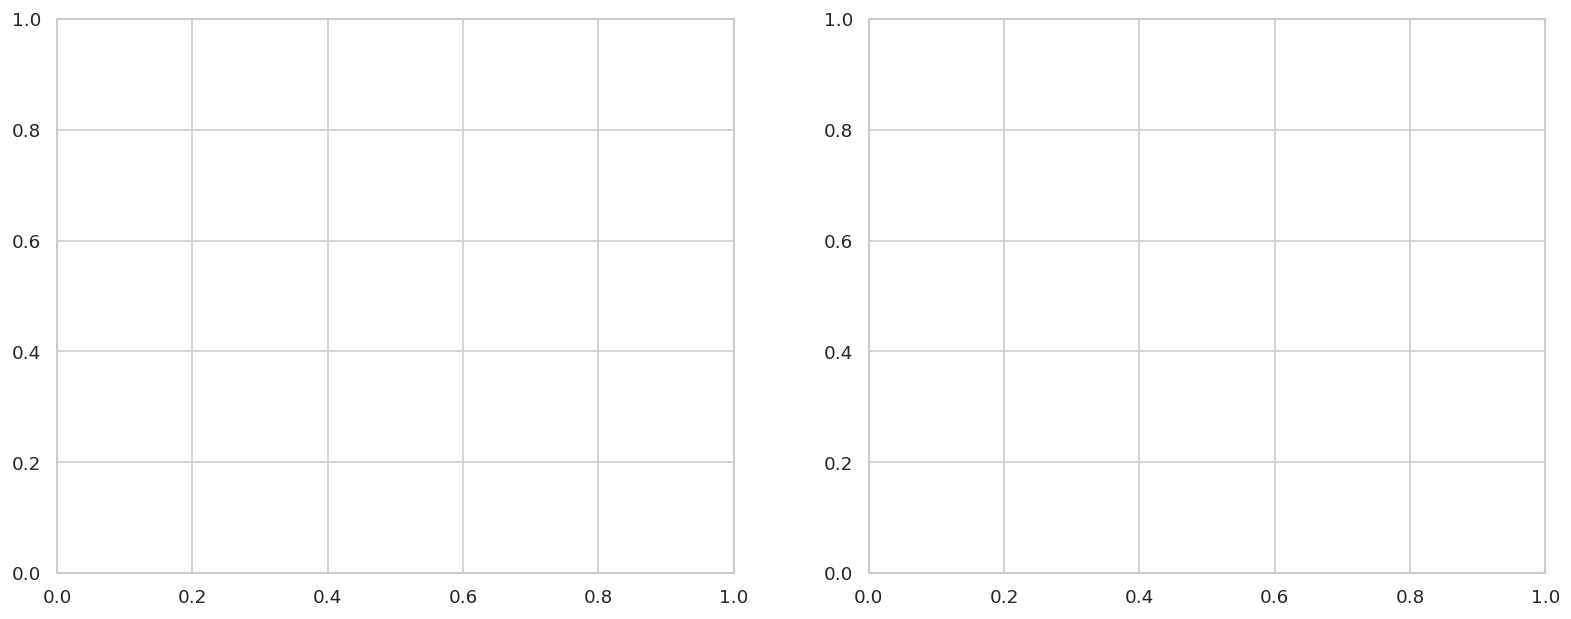

In [17]:
# 
# PHASE 5 – EVALUATION
# Cell 17: Comparative Visualization and ROC Curves
# 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grouped Bar Chart ---
x = np.arange(len(metrics_df.index))
width = 0.15
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metric_names, colors)):
    axes[0].bar(x + i * width, metrics_df[metric], width,
                label=metric, color=color, alpha=0.85)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics_df.index, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Model Performance Comparison\n(Notebook 2 — scale_pos_weight)',
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
# Reference line for target F1=0.70
axes[0].axhline(y=0.70, color='red', linestyle='--', alpha=0.5)

# --- ROC Curves ---
# The ROC curve shows the trade-off between detecting churners (TPR) and false alarms (FPR)
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})", linewidth=2)

# Diagonal line = random classifier (AUC=0.5) — minimum reference
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate — Recall (TPR)')
axes[1].set_title('ROC Curves — All Models\n(Notebook 2 — scale_pos_weight)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Phase 5 – Model Evaluation (scale_pos_weight)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nb2_04_model_comparison.png', bbox_inches='tight')
plt.show()